## Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Install Required Libraries

In [2]:
!pip install tensorflow transformers datasets transformers-interpret
!pip install torch torchvision
!pip install --upgrade tqdm
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00


## Import Essential Libraries

In [3]:
from bs4 import BeautifulSoup
import re, os, shutil
import pickle
import pandas as pd
import numpy as np
from datasets import DatasetDict, Dataset
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import activations, optimizers, losses

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)

import evaluate

## Create working directory

In [4]:
#
train_working_dir = "./training_cache"

if os.path.exists(train_working_dir):
    shutil.rmtree(train_working_dir)
    print(f"Dossier {train_working_dir} vidé pour un nouvel entraînement.")

os.makedirs(train_working_dir, exist_ok=True)

export_model_dir = "/content/drive/MyDrive/infotrustai_model_t2"
os.makedirs(export_model_dir , exist_ok=True)

dataset_path = "/content/drive/MyDrive/Colab Notebooks/data/WELFake_Dataset.csv"

## Load and Clean the Dataset:

In [5]:
df = pd.read_csv(dataset_path)

df.dropna(inplace=True)

df = df.loc[:,["text", "label"]]

# df.info()
# df.head()

## Clean and Deduplicate Text

In [6]:
def clean_text(text):
    if not isinstance(text, str):
          return ""  # If the input is not a string, return an empty string

    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

df['text'] = df['text'].apply(clean_text)

# Remove empty rows (if any were created during cleaning)
df = df[df["text"].str.strip() != ""]

# This helps ensure the model doesn’t learn repeated information
df = df.drop_duplicates(subset="text").reset_index(drop=True)

In [7]:
df.info()
df.head()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62094 entries, 0 to 62093
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    62094 non-null  object
 1   label   62094 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 970.3+ KB


(62094, 2)

## Define Evaluation Metrics

In [8]:
# Load metric calculators from Hugging Face
accuracy = evaluate.load("accuracy")
auc_score = evaluate.load("roc_auc")

#  Define a function to compute metrics during evaluation
def compute_metrics(eval_pred):
    predictions, labels = eval_pred  # Unpack model predictions and true labels

    # Convert logits to probabilities using softmax
    probabilities = np.exp(predictions) / np.exp(predictions).sum(-1, keepdims=True)
    positive_class_probs = probabilities[:, 1]  # Keep probabilities for class 1 (positive class)

    # Calculate AUC
    auc = auc_score.compute(prediction_scores=positive_class_probs, references=labels)['roc_auc']

    # Calculate accuracy
    acc = accuracy.compute(predictions=np.argmax(predictions, axis=1), references=labels)['accuracy']

    # Return rounded scores for easy reading
    return {"accuracy": round(acc, 3), "auc": round(auc, 3)}

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


## Convert to Hugging Face Dataset

In [9]:
df_dataset = Dataset.from_pandas(df)

## Model selection

In [10]:
model_path = "distilbert-base-uncased"

## Tokenizer

In [11]:

def tokenize_data(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_path)

#
tokenized_data = df_dataset.map(tokenize_data, batched=True)

# Prepare data collator for padding sequences
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/62094 [00:00<?, ? examples/s]

## Train/Validation/Test Split

In [12]:
train_test = tokenized_data.train_test_split(test_size=0.2, seed=42)
val_test = train_test["test"].train_test_split(test_size=0.5, seed=42)

final_dataset = DatasetDict({
    "train": train_test["train"],          # 80%
    "validation": val_test["train"],       # 10%
    "test": val_test["test"]               # 10%
})

## Model Fine-Tuning

In [13]:


# Load pre-trained DistilBERT model for sequence classification
model = AutoModelForSequenceClassification.from_pretrained(
    model_path, num_labels=2,
    id2label={0: "Fake", 1: "Real"},
    label2id={"Fake": 0, "Real": 1}
)


# Define training arguments
training_args = TrainingArguments(
    output_dir=train_working_dir,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="eval_accuracy",
    greater_is_better=True,
    logging_steps=50,
    fp16=True
)


# Define Trainer object for training the model
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=final_dataset["train"],
    eval_dataset=final_dataset["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

# Train the model
checkpoint_exists = os.path.exists(train_working_dir) and any("checkpoint" in d for d in os.listdir(train_working_dir))
trainer.train(resume_from_checkpoint=checkpoint_exists)

trainer.train(resume_from_checkpoint=True)



model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Auc
1,0.143264,0.063805,0.983000,0.998000
2,0.058370,0.077607,0.986000,0.999000
3,0.025106,0.070620,0.988000,0.999000
4,0.044404,0.069041,0.990000,0.999000
5,0.000005,0.099110,0.990000,0.998000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Epoch,Training Loss,Validation Loss


TrainOutput(global_step=31050, training_loss=0.0, metrics={'train_runtime': 0.0968, 'train_samples_per_second': 2566531.468, 'train_steps_per_second': 320848.725, 'total_flos': 3.2901590141184e+16, 'train_loss': 0.0, 'epoch': 5.0})

## Fine-Tuning Modele Backup

In [14]:
# Save the trained model
trainer.save_model(export_model_dir)
tokenizer.save_pretrained(export_model_dir)

print(f"Modèle et tokenizer sauvegardés avec succès dans : {export_model_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modèle et tokenizer sauvegardés avec succès dans : /content/drive/MyDrive/infotrustai_model_t2


## Evaluate on Test Set

In [15]:
eval_results = trainer.evaluate(eval_dataset=final_dataset["test"])
print(eval_results)

{'eval_loss': 0.0731651782989502, 'eval_accuracy': 0.989, 'eval_auc': 0.999, 'eval_runtime': 30.1969, 'eval_samples_per_second': 205.65, 'eval_steps_per_second': 25.731, 'epoch': 5.0}


## Plot AUC Curve and Confusion Matrix

In [16]:
# Prediction
y_true = final_dataset["test"]["label"]
predictions = trainer.predict(final_dataset["test"])
probs = np.exp(predictions.predictions) / np.exp(predictions.predictions).sum(-1, keepdims=True)
y_scores = probs[:, 1]
y_pred = np.argmax(predictions.predictions, axis=1)

In [17]:
# Classification report
c_report = classification_report(
    y_true,
    y_pred,
    target_names=["Fake", "Real"]
)

print("                   =============================")
print("                     RAPPORT DE CLASSIFICATION  ")
print("                   =============================")
print("\n")
print(c_report)

print("\n\n")

                     RAPPORT DE CLASSIFICATION  


              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      3455
        Real       0.99      0.99      0.99      2755

    accuracy                           0.99      6210
   macro avg       0.99      0.99      0.99      6210
weighted avg       0.99      0.99      0.99      6210






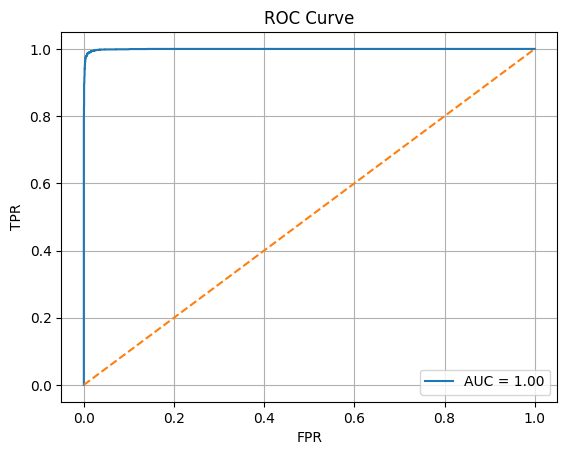

In [18]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_scores)
plt.plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.grid()
plt.show()

print("\n\n")

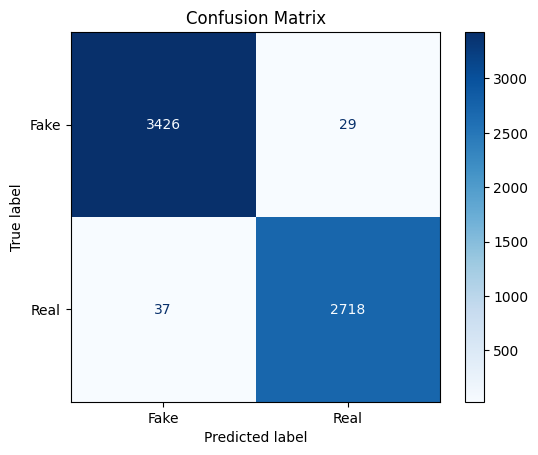

In [19]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake", "Real"]).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

## Demo

In [20]:
from transformers import pipeline
from transformers_interpret import SequenceClassificationExplainer

model_path = "/content/drive/MyDrive/infotrustai_model"

classifier = pipeline(
    "text-classification",
    model=model_path,
    tokenizer=model_path
)

Loading weights:   0%|          | 0/104 [00:03<?, ?it/s]

In [21]:
user_input = "The African Continental Free Trade Area (AfCFTA) has seen its first major phase of implementation, successfully reducing tariffs on 90% of goods traded between participating member states to boost intra-African commerce"

prediction = classifier(
    user_input,
    truncation=True
)

print(prediction)

[{'label': 'Fake', 'score': 0.9998400211334229}]


In [22]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer


c_model = AutoModelForSequenceClassification.from_pretrained(model_path)
c_tokenizer = AutoTokenizer.from_pretrained(model_path)


cls_explainer = SequenceClassificationExplainer(c_model, c_tokenizer)

word_attributions = cls_explainer(user_input)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [23]:
cls_explainer.predicted_class_name

'Fake'

In [24]:
word_attributions

[('[CLS]', 0.0),
 ('the', 0.4498524069786072),
 ('african', 0.20442922413349152),
 ('continental', 0.665585994720459),
 ('free', 0.1180773451924324),
 ('trade', 0.08281346410512924),
 ('area', 0.07318247109651566),
 ('(', 0.38223764300346375),
 ('afc', 0.027372844517230988),
 ('##ft', 0.0779811441898346),
 ('##a', 0.20550848543643951),
 (')', 0.17083759605884552),
 ('has', 0.0608261339366436),
 ('seen', 0.07968679815530777),
 ('its', 0.10853281617164612),
 ('first', -0.018016833811998367),
 ('major', 0.010730826295912266),
 ('phase', -0.010551941581070423),
 ('of', 0.01974744349718094),
 ('implementation', 0.029573697596788406),
 (',', 0.08536329865455627),
 ('successfully', -0.023939648643136024),
 ('reducing', 0.06544526666402817),
 ('tariffs', 0.08169086277484894),
 ('on', 0.058071501553058624),
 ('90', 0.048463139683008194),
 ('%', 0.038797978311777115),
 ('of', 0.0159086175262928),
 ('goods', 0.018901154398918152),
 ('traded', 0.0686149075627327),
 ('between', 0.034463971853256226

In [25]:
cls_explainer.visualize("distilbert_example.html")

In [26]:
def extract_keywords(explanation, threshold=0.05, top_k=5):
    words = [
        word for word, score in explanation
        if abs(score) > threshold and word not in ["[CLS]", "[SEP]"]
    ]
    return words[:top_k]

In [27]:
extract_keywords(word_attributions)

['the', 'african', 'continental', 'free', 'trade']